In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

In [3]:
DATA_DIR = r"C:\Users\hp\OneDrive\Desktop\DeepVision-Traffic-Sign-Recognition\Data"

TRAIN_DIR = os.path.join(DATA_DIR, "Train")
TEST_DIR = os.path.join(DATA_DIR, "Test")

print("Train path:", TRAIN_DIR)
print("Test path:", TEST_DIR)

print("Train exists:", os.path.exists(TRAIN_DIR))
print("Test exists:", os.path.exists(TEST_DIR))

Train path: C:\Users\hp\OneDrive\Desktop\DeepVision-Traffic-Sign-Recognition\Data\Train
Test path: C:\Users\hp\OneDrive\Desktop\DeepVision-Traffic-Sign-Recognition\Data\Test
Train exists: True
Test exists: True


In [4]:
classes = sorted([
        folder for folder in os.listdir(TRAIN_DIR)
        if os.path.isdir(os.path.join(TRAIN_DIR, folder))],key=lambda x: int(x))
print("Number of classes:", len(classes))
print("Classes:", classes)

Number of classes: 43
Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42']


In [5]:
image_extensions = (".png", ".jpg", ".jpeg")
class_counts = {}
for class_name in classes:
    class_path = os.path.join(TRAIN_DIR, class_name)
    count = sum(
        1
        for file in os.listdir(class_path)
        if file.lower().endswith(image_extensions)
    )
    class_counts[int(class_name)] = count
class_distribution = pd.Series(class_counts).sort_index()
print("Total training images:", class_distribution.sum())
print(class_distribution)

Total training images: 39209
0      210
1     2220
2     2250
3     1410
4     1980
5     1860
6      420
7     1440
8     1410
9     1470
10    2010
11    1320
12    2100
13    2160
14     780
15     630
16     420
17    1110
18    1200
19     210
20     360
21     330
22     390
23     510
24     270
25    1500
26     600
27     240
28     540
29     270
30     450
31     780
32     240
33     689
34     420
35    1200
36     390
37     210
38    2070
39     300
40     360
41     240
42     240
dtype: int64


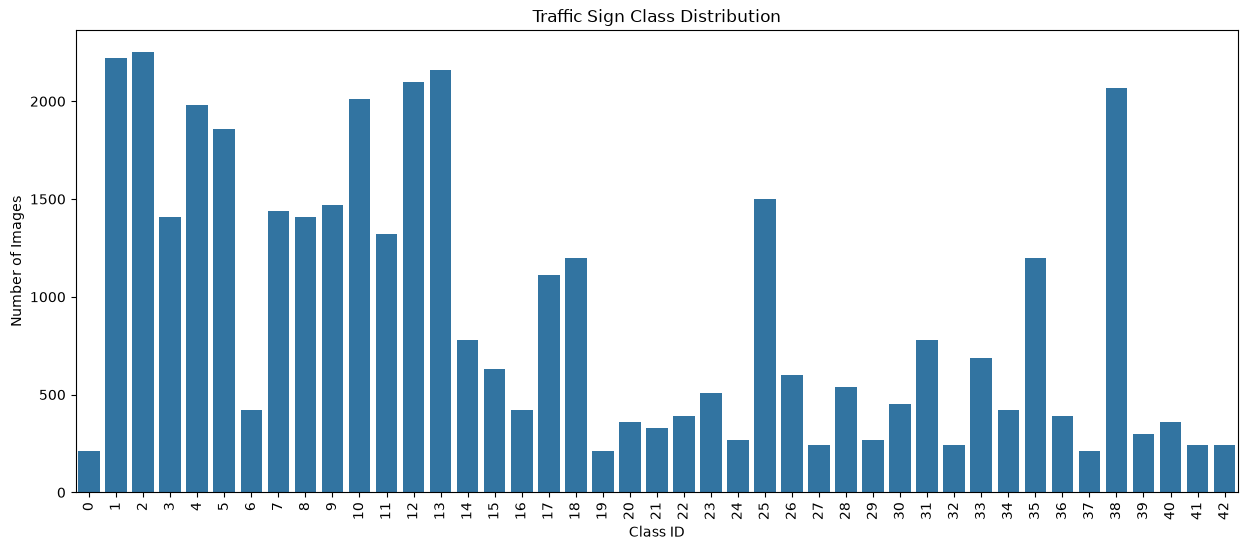

In [6]:
plt.figure(figsize=(15, 6))
sns.barplot(x=class_distribution.index,y=class_distribution.values)
plt.title("Traffic Sign Class Distribution")
plt.xlabel("Class ID")
plt.ylabel("Number of Images")
plt.xticks(rotation=90)
plt.show()

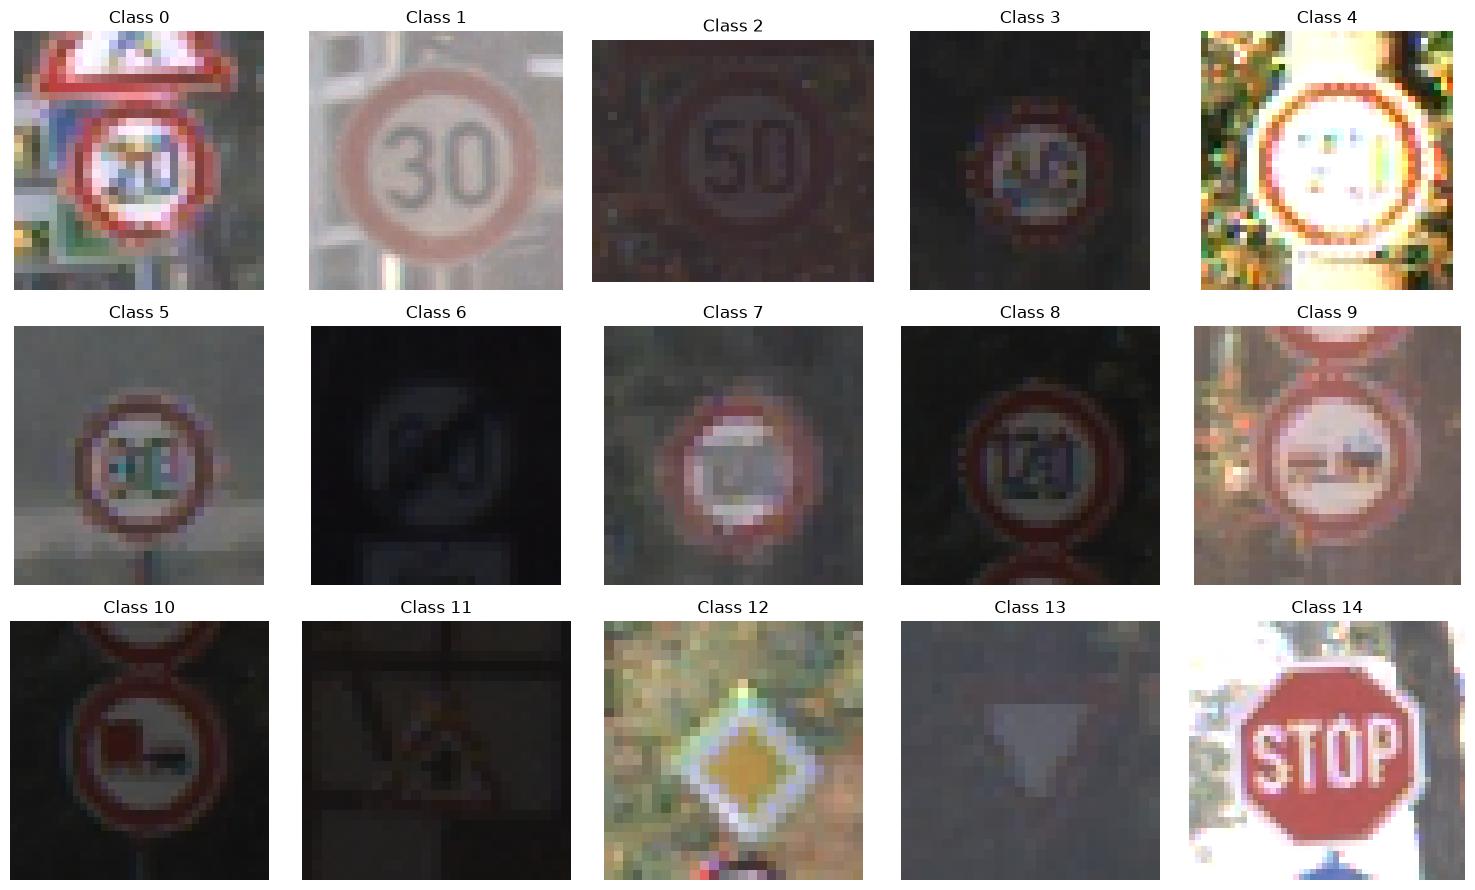

In [7]:
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
for ax, class_name in zip(axes.flatten(), classes[:15]):
    class_path = os.path.join(TRAIN_DIR, class_name)
    image_files = [
        file for file in os.listdir(class_path)
        if file.lower().endswith(image_extensions)
    ]
    image_path = os.path.join(class_path, image_files[0])
    image = Image.open(image_path)
    ax.imshow(image)
    ax.set_title(f"Class {class_name}")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [8]:
sizes = []
for class_name in classes:
    class_path = os.path.join(TRAIN_DIR, class_name)
    image_files = [
        file for file in os.listdir(class_path)
        if file.lower().endswith(image_extensions)
    ]
    # Sample 30 images per class to save time
    for image_file in image_files[:30]:
        image_path = os.path.join(class_path, image_file)
        with Image.open(image_path) as img:
            sizes.append(img.size)
widths = [size[0] for size in sizes]
heights = [size[1] for size in sizes]
print("Images checked:", len(sizes))
print("Width  - Min:", min(widths), "Max:", max(widths))
print("Height - Min:", min(heights), "Max:", max(heights))

Images checked: 1290
Width  - Min: 25 Max: 221
Height - Min: 25 Max: 195


In [9]:
corrupted_images = []
for class_name in classes:
    class_path = os.path.join(TRAIN_DIR, class_name)
    for image_file in os.listdir(class_path):
        if image_file.lower().endswith(image_extensions):
            image_path = os.path.join(class_path, image_file)
            try:
                with Image.open(image_path) as img:
                    img.verify()
            except Exception:
                corrupted_images.append(image_path)
print("Corrupted images:", len(corrupted_images))
if corrupted_images:
    print(corrupted_images[:10])

Corrupted images: 0
